In [1]:
import pandas as pd
import numpy as np

avax_preds = pd.read_csv('Coin_Models/avax_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')
sol_preds = pd.read_csv('Coin_Models/sol_orders.csv')
dot_preds = pd.read_csv('Coin_Models/dot_orders.csv')
matic_preds = pd.read_csv('Coin_Models/matic_orders.csv')

avax_prices = pd.read_parquet('data/price_data/processed/aval_processed_data.parquet')
dot_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/dot_price_processed.parquet')
matic_prices = pd.read_parquet('data/price_data/processed/matic_processed_data.parquet')
near_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/near_price_processed.parquet')
sol_prices = pd.read_parquet('data/price_data/processed/sol_processed_data.parquet')

In [2]:
dot_prices['time_period_end'] = dot_prices.index
dot_prices.index = np.arange(len(dot_prices))

near_prices['time_period_end'] = near_prices.index
near_prices.index = np.arange(len(near_prices))

In [3]:
# Define the split index for 70% training data
split_index = len(avax_preds)
avax_prices = avax_prices[-split_index:].reset_index().drop(columns=['index'])
avax_preds['time'] = avax_prices['time_period_end']
avax_preds = avax_preds[(avax_preds['time'] >= '2024-01-01') & (avax_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
avax_prices = avax_prices[(avax_prices['time_period_end'] >= '2024-01-01') & (avax_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(near_preds)
near_prices = near_prices[-split_index:].reset_index().drop(columns=['index'])
near_preds['time'] = near_prices['time_period_end']
near_preds = near_preds[(near_preds['time'] >= '2024-01-01') & (near_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
near_prices = near_prices[(near_prices['time_period_end'] >= '2024-01-01') & (near_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(sol_preds)
sol_prices = sol_prices[-split_index:].reset_index().drop(columns=['index'])
sol_preds['time'] = sol_prices['time_period_end']
sol_preds = sol_preds[(sol_preds['time'] >= '2024-01-01') & (sol_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
sol_prices = sol_prices[(sol_prices['time_period_end'] >= '2024-01-01') & (sol_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(dot_preds)
dot_prices = dot_prices[-split_index:].reset_index().drop(columns=['index'])
dot_preds['time'] = dot_prices['time_period_end']
dot_preds = dot_preds[(dot_preds['time'] >= '2024-01-01') & (dot_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
dot_prices = dot_prices[(dot_prices['time_period_end'] >= '2024-01-01') & (dot_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(matic_preds)
matic_prices = matic_prices[-split_index:].reset_index().drop(columns=['index'])
matic_preds['time'] = matic_prices['time_period_end']
matic_preds = matic_preds[(matic_preds['time'] >= '2024-01-01') & (matic_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
matic_prices = matic_prices[(matic_prices['time_period_end'] >= '2024-01-01') & (matic_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

In [4]:
dfs = {
    "AVAX": avax_preds,
    "NEAR": near_preds,
    "SOL": sol_preds,
    "DOT": dot_preds,
    "MATIC": matic_preds
}

price_dfs = {
    "AVAX": avax_prices,
    "DOT": dot_prices,
    "MATIC": matic_prices,
    "NEAR": near_prices,
    "SOL": sol_prices
}

In [5]:
avax_preds.drop(columns='Unnamed: 0', inplace=True)
near_preds.drop(columns='Unnamed: 0', inplace=True)
sol_preds.drop(columns='Unnamed: 0', inplace=True)
dot_preds.drop(columns='Unnamed: 0', inplace=True)
matic_preds.drop(columns='Unnamed: 0', inplace=True)

In [6]:
'''import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities,
    with capital constraints.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin
    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin

    all_results = {} # store results for all coins

    for coin, df in dfs.items():
        results = [] # store results for current coin
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100

            investment_amount = 0
            trading_fee = 0.001

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + (trading_fee * investment_amount)
                    coin_holdings[coin] += investment_amount # track stock holdings
                else:
                    investment_amount = 0 # no cash, no buy

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                  investment_amount = -min(available_holdings, max_investment_per_coin * prob_sell)
                  coin_investments[coin] += investment_amount
                  coin_cash[coin] -= investment_amount # add cash from sale
                  coin_holdings[coin] += investment_amount # reduce stock holdings
                else:
                  investment_amount = 0 # no stock, no sell

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    total_investment = pd.Series([0] * len(next(iter(results.values())))) # initialize with zeros

    for coin_result in results.values():
        total_investment += coin_result['Investment'].cumsum()

    pnl = total_investment
    cumulative_capital = initial_capital + pnl
    return pnl, cumulative_capital

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names) # use number of coins

results = calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)'''

'import pandas as pd\nimport matplotlib.pyplot as plt\n\ndef calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):\n    """\n    Calculates investment amounts for each coin based on predicted classifications and probabilities,\n    with capital constraints.\n    """\n\n    max_investment_per_coin = starting_capital / portfolio_size\n    coin_investments = {coin: 0 for coin in coin_names}\n    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin\n    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin\n\n    all_results = {} # store results for all coins\n\n    for coin, df in dfs.items():\n        results = [] # store results for current coin\n        for index, row in df.iterrows():\n            prediction = row["Prediction"]\n            prob_buy = row["Probability Buy"] / 100\n            prob_sell = row["Probability Sell"] / 100\n\n            investment_amount = 0\n            trading_f

{'AVAX':       Prediction  Probability Buy  Probability Sell  Investment  \
 0            2.0         0.085139          0.463681         0.0   
 1            0.0         0.082291          0.427662         0.0   
 2            2.0         0.089812          0.466062         0.0   
 3            0.0         0.072257          0.384954         0.0   
 4            0.0         0.060939          0.314318         0.0   
 ...          ...              ...               ...         ...   
 6043         1.0         0.964441          0.005760         0.0   
 6044         1.0         0.975830          0.003840         0.0   
 6045         1.0         0.953607          0.007307         0.0   
 6046         1.0         0.943280          0.010137         0.0   
 6047         1.0         0.962524          0.005542         0.0   
 
       Cash Holdings  Stock Holdings    Coin Value  Total Portfolio Value  
 0           20000.0        0.000000      0.000000          100000.000000  
 1           20000.0  

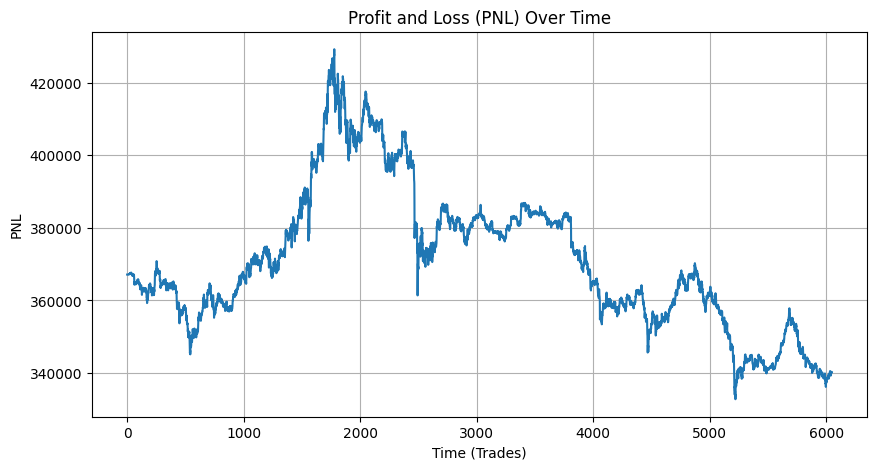

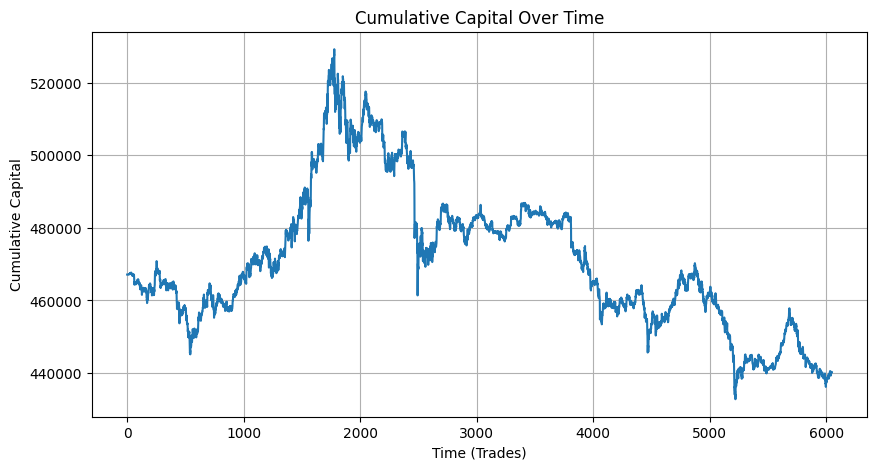


AVAX Results:
      Prediction  Probability Buy  Probability Sell  Investment  \
0            2.0         0.085139          0.463681         0.0   
1            0.0         0.082291          0.427662         0.0   
2            2.0         0.089812          0.466062         0.0   
3            0.0         0.072257          0.384954         0.0   
4            0.0         0.060939          0.314318         0.0   
...          ...              ...               ...         ...   
6043         1.0         0.964441          0.005760         0.0   
6044         1.0         0.975830          0.003840         0.0   
6045         1.0         0.953607          0.007307         0.0   
6046         1.0         0.943280          0.010137         0.0   
6047         1.0         0.962524          0.005542         0.0   

      Cash Holdings  Stock Holdings    Coin Value  Total Portfolio Value  
0           20000.0        0.000000      0.000000          100000.000000  
1           20000.0        0.0

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100
            current_price = price_df.loc[index, 'Close']# if index in price_df.index else price_df['Close'].iloc[price_df.index.get_loc(index, method='ffill')] # get current price, ffill if missing

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

display(results)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    print(result_df)